# Prédiction du prix des logements en Californie

## 1. Introduction

### Contexte

L'estimation de la valeur des logements constitue un problème classique
de régression en Data Science.

Dans ce projet, nous allons analyser les caractéristiques de différents
districts de Californie afin d'étudier les facteurs associés à la valeur
médiane des logements et de construire des modèles capables de l'estimer.

### Objectifs

Ce projet suit une démarche complète de Data Science :

- explorer et comprendre les données ;
- analyser les principales relations entre les variables ;
- préparer les données pour la modélisation ;
- construire plusieurs modèles de Machine Learning ;
- comparer leurs performances ;
- interpréter les résultats ;
- analyser les erreurs et les limites du modèle.

### Technologies utilisées

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

sns.set_theme(style="whitegrid")

print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


In [4]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)

df = housing.frame.copy()

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Nombre de lignes : 20640
Nombre de colonnes : 9


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [8]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


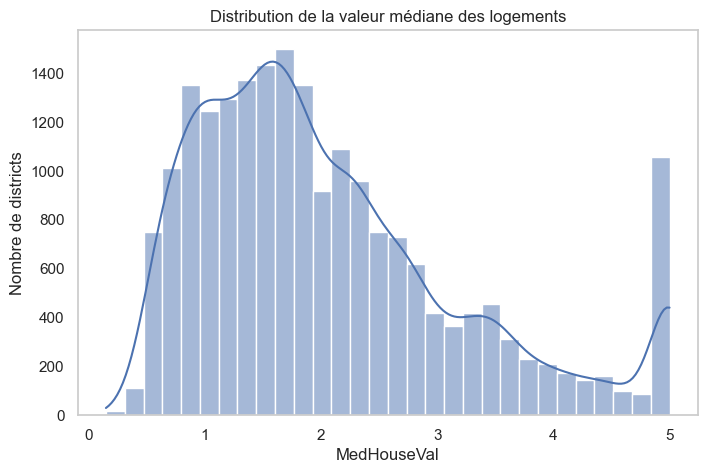

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(df["MedHouseVal"], bins=30, kde=True)

plt.title("Distribution de la valeur médiane des logements")
plt.xlabel("MedHouseVal")
plt.ylabel("Nombre de districts")
plt.grid()
plt.show()

### Observation

La distribution de `MedHouseVal` est relativement étalée et présente une
concentration importante des valeurs entre 1 et 3.

On observe également un pic marqué à la valeur 5. Cette concentration
s'explique par le plafonnement de la variable cible dans le jeu de données.

La distribution n'est donc pas parfaitement symétrique, ce qui devra être
pris en compte lors de l'analyse et de l'évaluation des modèles.

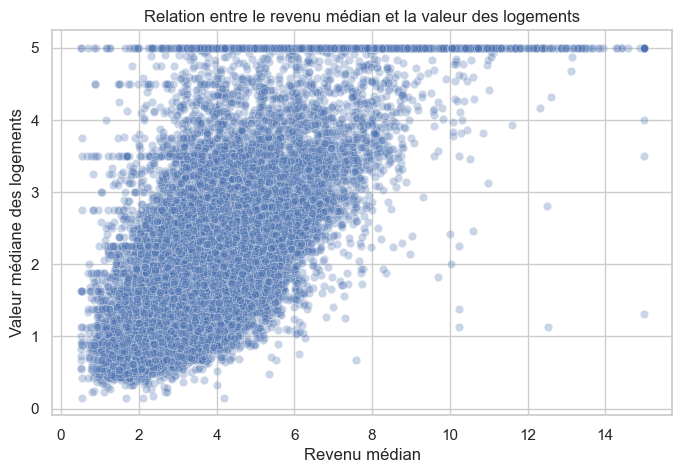

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="MedInc",
    y="MedHouseVal",
    alpha=0.3
)

plt.title("Relation entre le revenu médian et la valeur des logements")
plt.xlabel("Revenu médian")
plt.ylabel("Valeur médiane des logements")

plt.show()

### Observation

Le nuage de points met en évidence une relation positive entre le revenu
médian (`MedInc`) et la valeur médiane des logements (`MedHouseVal`).

De manière générale, les districts présentant un revenu médian plus élevé
ont tendance à avoir une valeur médiane des logements plus importante.

Cependant, la dispersion des observations montre que le revenu n'explique
pas à lui seul la valeur des logements. D'autres variables, notamment la
localisation géographique et les caractéristiques des logements, peuvent
également jouer un rôle important.

In [11]:
correlation = df.corr()

correlation

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


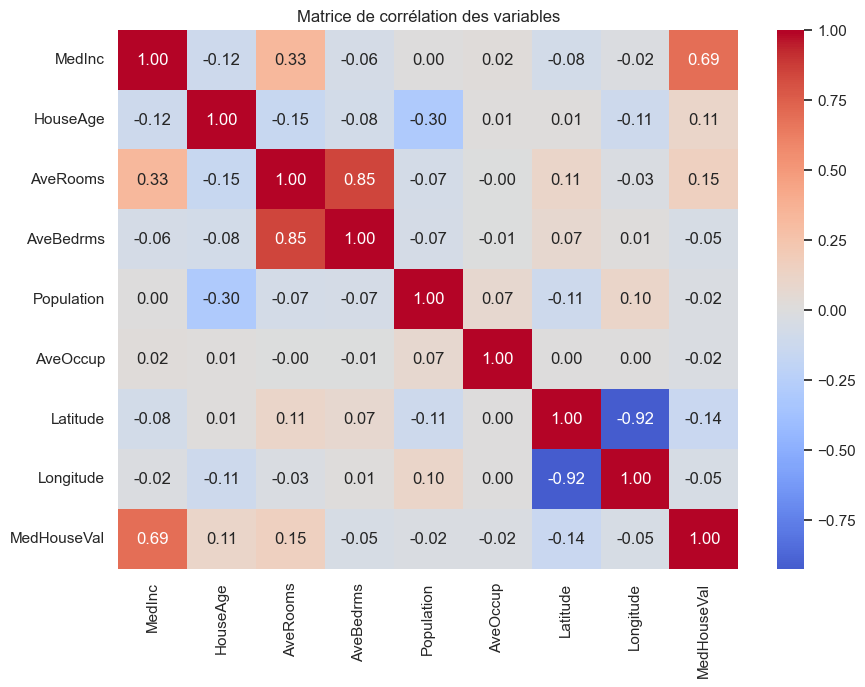

In [12]:
import seaborn as sns
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matrice de corrélation des variables")
plt.show()

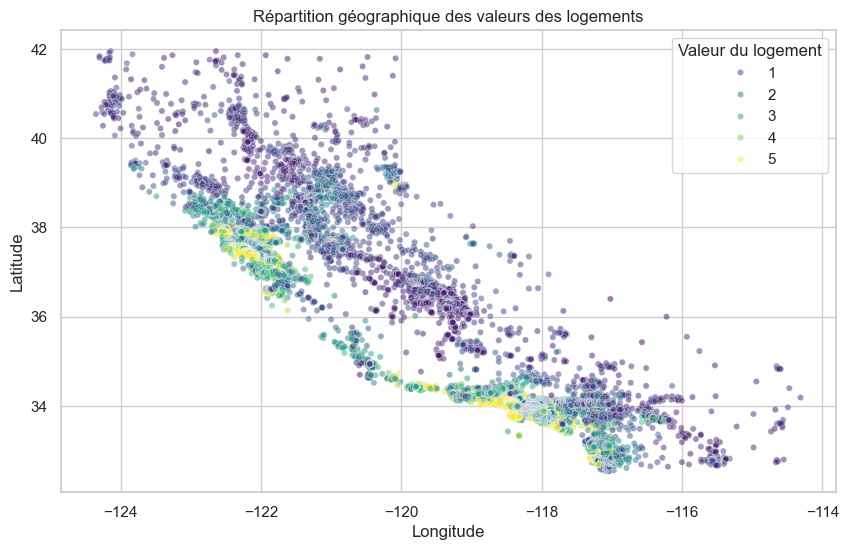

In [13]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude",
    hue="MedHouseVal",
    palette="viridis",
    alpha=0.5,
    s=20
)

plt.title("Répartition géographique des valeurs des logements")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Valeur du logement")

plt.show()

### Analyse de la répartition géographique

La représentation géographique montre que la valeur des logements varie
selon leur localisation.

Les valeurs élevées de `MedHouseVal` ne sont pas réparties uniformément
sur le territoire. Elles se concentrent davantage dans certaines zones.

Cette observation montre que les variables `Latitude` et `Longitude`
peuvent apporter une information utile à la prédiction, même si leur
corrélation linéaire individuelle avec `MedHouseVal` reste relativement
faible.

La relation entre la localisation et la valeur des logements peut donc
être plus complexe qu'une simple relation linéaire.

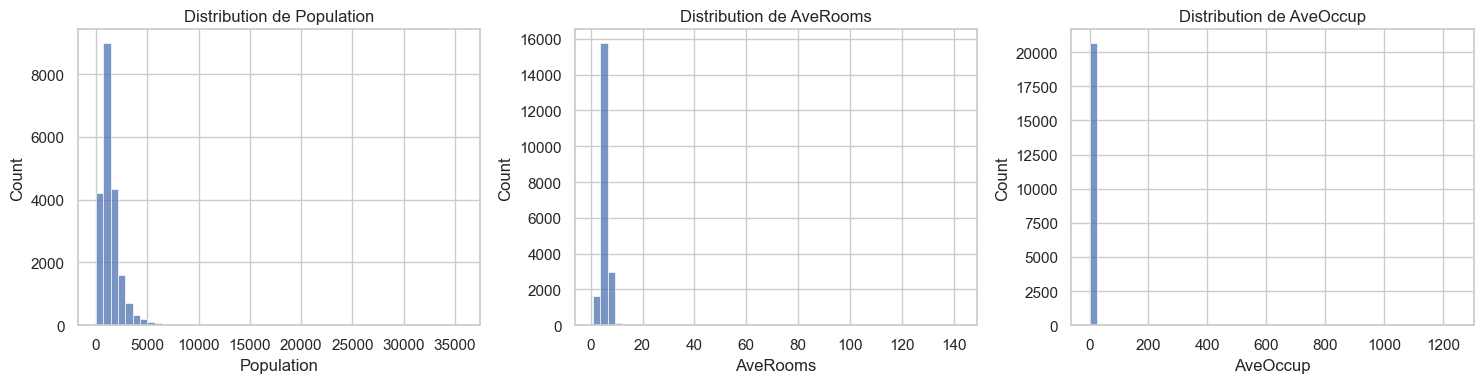

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["Population"], bins=50, ax=axes[0])
axes[0].set_title("Distribution de Population")

sns.histplot(df["AveRooms"], bins=50, ax=axes[1])
axes[1].set_title("Distribution de AveRooms")

sns.histplot(df["AveOccup"], bins=50, ax=axes[2])
axes[2].set_title("Distribution de AveOccup")

plt.tight_layout()
plt.show()

### Analyse des distributions

Les variables `Population`, `AveRooms` et `AveOccup` présentent des
distributions fortement asymétriques.

La majorité des observations est concentrée sur des valeurs relativement
faibles, tandis que quelques observations présentent des valeurs très
élevées.

Ces valeurs extrêmes devront être prises en compte lors de la préparation
des données. Elles ne seront pas supprimées automatiquement afin de
conserver l'ensemble des observations disponibles.

In [15]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (20640, 8)
Dimensions de y : (20640,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (16512, 8)
X_test  : (4128, 8)
y_train : (16512,)
y_test  : (4128,)


In [17]:
from sklearn.linear_model import LinearRegression

modele_lineaire = LinearRegression()

modele_lineaire.fit(X_train, y_train)

print("Modèle entraîné avec succès.")

Modèle entraîné avec succès.


In [18]:
y_pred = modele_lineaire.predict(X_test)

print("Nombre de prédictions :", len(y_pred))

Nombre de prédictions : 4128


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)

MAE  : 0.5332001304956554
RMSE : 0.7455813830127761
R²   : 0.5757877060324511


### Résultats — Régression linéaire

La régression linéaire obtient les performances suivantes sur l'ensemble
de test :

- MAE : 0,5332
- RMSE : 0,7456
- R² : 0,5758

Le modèle explique environ 57,6 % de la variabilité de la variable cible.
Ces résultats constituent une première référence qui permettra de comparer
les performances des modèles plus complexes.

In [20]:
from sklearn.ensemble import RandomForestRegressor

modele_forest = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

modele_forest.fit(X_train, y_train)

print("Random Forest entraîné avec succès.")

Random Forest entraîné avec succès.


In [21]:
y_pred_forest = modele_forest.predict(X_test)

print("Nombre de prédictions :", len(y_pred_forest))

Nombre de prédictions : 4128


In [22]:
mae_forest = mean_absolute_error(y_test, y_pred_forest)
rmse_forest = np.sqrt(mean_squared_error(y_test, y_pred_forest))
r2_forest = r2_score(y_test, y_pred_forest)

print("MAE  :", mae_forest)
print("RMSE :", rmse_forest)
print("R²   :", r2_forest)

MAE  : 0.32665595592700286
RMSE : 0.5037464443416994
R²   : 0.8063501667032575


### Comparaison : Régression linéaire vs Random Forest

Le Random Forest obtient de meilleures performances que la régression
linéaire sur l'ensemble de test.

| Modèle | MAE | RMSE | R² |
|---|---:|---:|---:|
| Régression linéaire | 0,5332 | 0,7456 | 0,5758 |
| Random Forest | 0,3267 | 0,5037 | 0,8064 |

Le Random Forest réduit les erreurs de prédiction et obtient un coefficient
de détermination plus élevé. Cela suggère que les relations entre les
variables explicatives et la valeur des logements ne sont pas entièrement
linéaires.

In [23]:
from sklearn.ensemble import GradientBoostingRegressor

modele_gradient = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

modele_gradient.fit(X_train, y_train)

print("Gradient Boosting entraîné avec succès.")

Gradient Boosting entraîné avec succès.


In [24]:
y_pred_gradient = modele_gradient.predict(X_test)

print("Nombre de prédictions :", len(y_pred_gradient))

Nombre de prédictions : 4128


In [25]:
mae_gradient = mean_absolute_error(y_test, y_pred_gradient)
rmse_gradient = np.sqrt(mean_squared_error(y_test, y_pred_gradient))
r2_gradient = r2_score(y_test, y_pred_gradient)

print("MAE  :", mae_gradient)
print("RMSE :", rmse_gradient)
print("R²   :", r2_gradient)

MAE  : 0.3551100358073948
RMSE : 0.5216157896982243
R²   : 0.7923678511209928


### Comparaison des modèles

Les trois modèles ont été évalués sur le même ensemble de test à l'aide
des métriques MAE, RMSE et R².

| Modèle | MAE | RMSE | R² |
|---|---:|---:|---:|
| Régression linéaire | 0,5332 | 0,7456 | 0,5758 |
| Random Forest | 0,3267 | 0,5037 | 0,8064 |
| Gradient Boosting | 0,3551 | 0,5216 | 0,7924 |

Les modèles basés sur les arbres obtiennent de meilleures performances
que la régression linéaire sur cet ensemble de test. Les résultats
montrent également des différences entre Random Forest et Gradient
Boosting, malgré leur capacité commune à modéliser des relations
non linéaires.

In [26]:
resultats = pd.DataFrame({
    "Modèle": [
        "Régression linéaire",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae,
        mae_forest,
        mae_gradient
    ],
    "RMSE": [
        rmse,
        rmse_forest,
        rmse_gradient
    ],
    "R²": [
        r2,
        r2_forest,
        r2_gradient
    ]
})

resultats

,Modèle,MAE,RMSE,R²
0,Régression linéaire,0.533200,0.745581,0.575788
1,Random Forest,0.326656,0.503746,0.806350
2,Gradient Boosting,0.355110,0.521616,0.792368


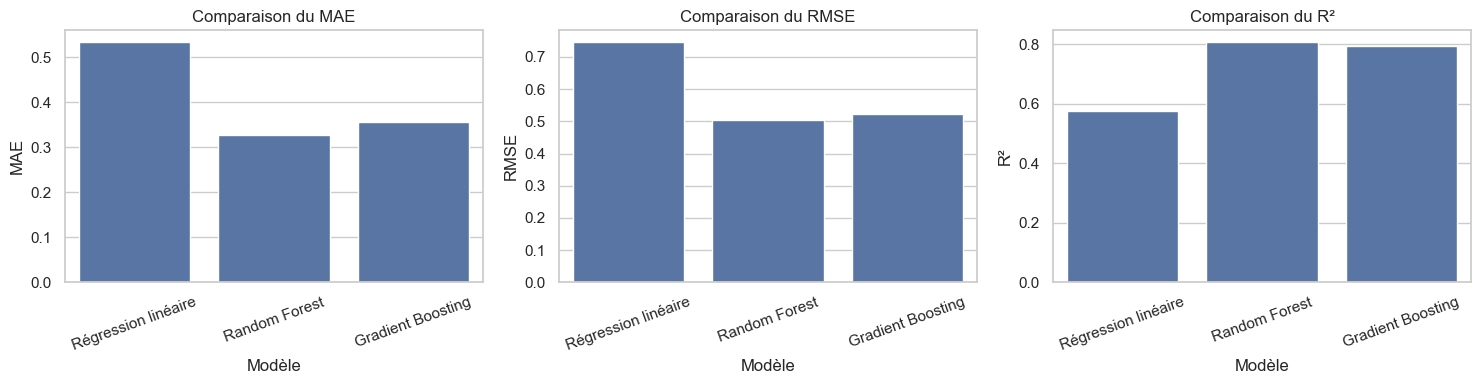

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=resultats, x="Modèle", y="MAE", ax=axes[0])
axes[0].set_title("Comparaison du MAE")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=resultats, x="Modèle", y="RMSE", ax=axes[1])
axes[1].set_title("Comparaison du RMSE")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(data=resultats, x="Modèle", y="R²", ax=axes[2])
axes[2].set_title("Comparaison du R²")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [28]:
importance = pd.DataFrame({
    "Variable": X_train.columns,
    "Importance": modele_forest.feature_importances_
}).sort_values("Importance", ascending=False)

importance

,Variable,Importance
0,MedInc,0.525738
5,AveOccup,0.138064
6,Latitude,0.088634
7,Longitude,0.088417
1,HouseAge,0.054257
2,AveRooms,0.044600
4,Population,0.030604
3,AveBedrms,0.029687


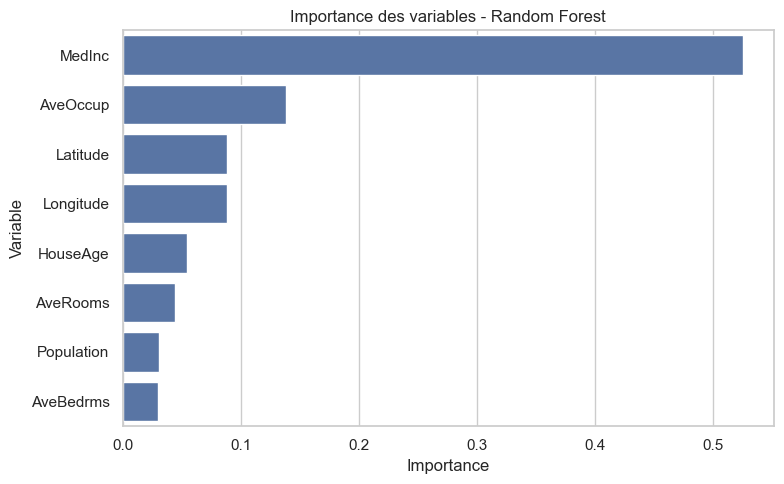

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Variable"
)

plt.title("Importance des variables - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

### Interprétation de l'importance des variables

L'analyse de l'importance des variables du modèle Random Forest montre que
`MedInc` (revenu médian) est la variable la plus importante pour les
prédictions, avec une importance d'environ 0,53.

Les variables `AveOccup`, `Latitude` et `Longitude` présentent également
une contribution importante au modèle.

Les variables `HouseAge`, `AveRooms`, `Population` et `AveBedrms` ont une
importance plus faible dans ce modèle.

Ces résultats indiquent que le modèle utilise principalement les
informations relatives au revenu, à l'occupation des logements et à la
localisation géographique pour prédire la valeur médiane des logements.

Il faut toutefois préciser que l'importance calculée par
`feature_importances_` mesure l'utilisation des variables par les arbres
du Random Forest et ne signifie pas nécessairement qu'une variable est
causalement responsable de la valeur prédite.

In [30]:
from sklearn.inspection import permutation_importance

permutation = permutation_importance(
    modele_forest,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=1,
    scoring="r2"
)

importance_permutation = pd.DataFrame({
    "Variable": X_test.columns,
    "Importance": permutation.importances_mean
}).sort_values("Importance", ascending=False)

importance_permutation

,Variable,Importance
0,MedInc,0.737990
6,Latitude,0.441610
7,Longitude,0.335329
5,AveOccup,0.202163
1,HouseAge,0.071789
2,AveRooms,0.027056
3,AveBedrms,0.009429
4,Population,0.008194


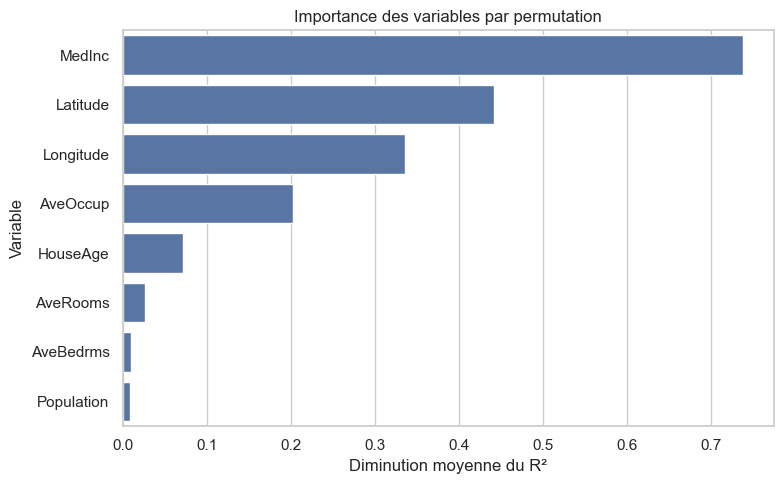

In [31]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance_permutation,
    x="Importance",
    y="Variable"
)

plt.title("Importance des variables par permutation")
plt.xlabel("Diminution moyenne du R²")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

### Analyse de l'importance par permutation

L'analyse par permutation confirme l'importance de certaines variables
identifiées précédemment.

`MedInc` présente la plus forte diminution moyenne du R² (0,7380), ce qui
indique que le modèle dépend fortement de cette variable pour ses
prédictions.

Les variables `Latitude` (0,4416) et `Longitude` (0,3353) présentent
également une importance élevée. La localisation géographique apporte donc
une information significative pour prédire la valeur des logements.

`AveOccup` présente également une contribution notable, tandis que
`HouseAge`, `AveRooms`, `AveBedrms` et `Population` ont un impact plus
limité selon cette méthode.

Cette analyse complète l'importance des variables calculée directement à
partir des arbres du Random Forest.

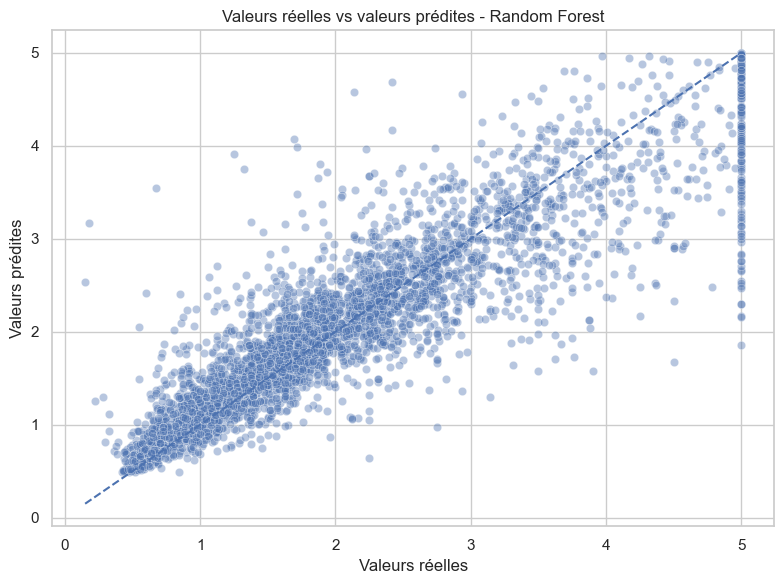

In [32]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_forest,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Valeurs réelles vs valeurs prédites - Random Forest")
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")

plt.tight_layout()
plt.show()

In [33]:
erreurs = y_test - y_pred_forest

print("Erreur moyenne :", erreurs.mean())
print("Erreur minimale :", erreurs.min())
print("Erreur maximale :", erreurs.max())
print("Écart-type des erreurs :", erreurs.std())

Erreur moyenne : -0.012153287661497841
Erreur minimale : -2.9974541333333335
Erreur maximale : 3.1416799333333323
Écart-type des erreurs : 0.5036608282132861


### Analyse des erreurs de prédiction

L'erreur moyenne du modèle est de -0,0122, ce qui est très proche de zéro.
Cela indique l'absence d'un biais moyen important dans les prédictions.

Les erreurs observées varient entre -2,9975 et 3,1417. Le modèle peut donc
présenter des écarts importants pour certaines observations.

L'écart-type des erreurs est de 0,5037, ce qui indique une dispersion
modérée des erreurs autour de leur moyenne.

Globalement, cette analyse complète les métriques précédentes et permet
d'étudier plus précisément le comportement des prédictions du Random Forest.

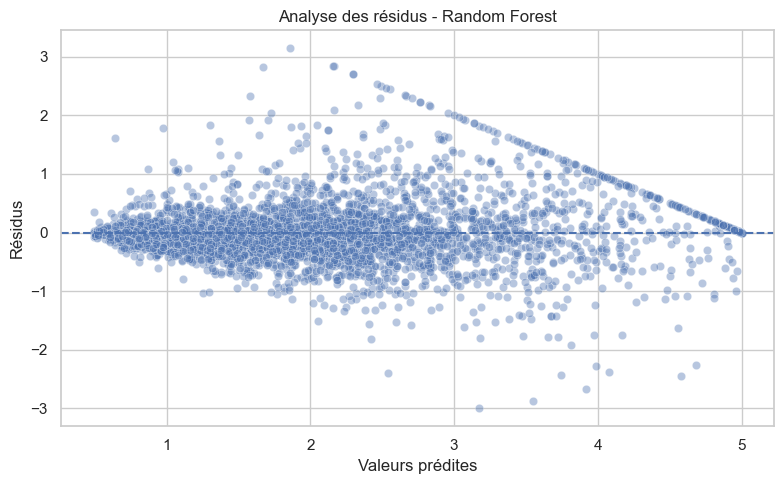

In [34]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_pred_forest,
    y=erreurs,
    alpha=0.4
)

plt.axhline(0, linestyle="--")

plt.title("Analyse des résidus - Random Forest")
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")

plt.tight_layout()
plt.show()

In [35]:
resultats_final = resultats.copy()

resultats_final = resultats_final.round(4)

resultats_final

,Modèle,MAE,RMSE,R²
0,Régression linéaire,0.5332,0.7456,0.5758
1,Random Forest,0.3267,0.5037,0.8064
2,Gradient Boosting,0.3551,0.5216,0.7924


# Conclusion

### Bilan du projet

L'objectif de ce projet était de prédire la valeur médiane des logements
en Californie à partir de différentes caractéristiques socio-économiques,
démographiques et géographiques.

Trois modèles de régression ont été étudiés : la régression linéaire,
le Random Forest et le Gradient Boosting. Les performances ont été
comparées à l'aide du MAE, du RMSE et du coefficient de détermination R².

Les résultats obtenus montrent que le Random Forest présente un R² de
0,8064, avec un MAE de 0,3267 et un RMSE de 0,5037 sur l'ensemble de test.

L'analyse de l'importance des variables montre que `MedInc` est fortement
utilisée par le modèle. Les variables `Latitude` et `Longitude` apportent
également une information importante, ce qui met en évidence le rôle de
la localisation dans les prédictions.

L'analyse par permutation confirme notamment l'importance de `MedInc`,
ainsi que celle de `Latitude` et `Longitude`.

Enfin, l'analyse des erreurs montre une erreur moyenne proche de zéro
(-0,0122), tandis que certaines observations présentent des écarts plus
importants entre les valeurs réelles et les valeurs prédites.

Ce projet m'a permis de mettre en pratique une démarche complète de
Machine Learning, depuis l'exploration et la préparation des données
jusqu'à l'entraînement, l'évaluation et l'interprétation des modèles.

In [36]:
import os

print(os.getcwd())

C:\Users\21518348\California_Housing_Price_Prediction.ipnb\California_Housing_Price_Prediction\notebooks


In [37]:
import joblib

joblib.dump(
    modele_forest,
    "../models/random_forest_california_housing.joblib"
)

print("Modèle Random Forest sauvegardé avec succès.")

Modèle Random Forest sauvegardé avec succès.


In [38]:
import os

os.makedirs("../reports", exist_ok=True)

print("Dossier reports prêt.")

Dossier reports prêt.


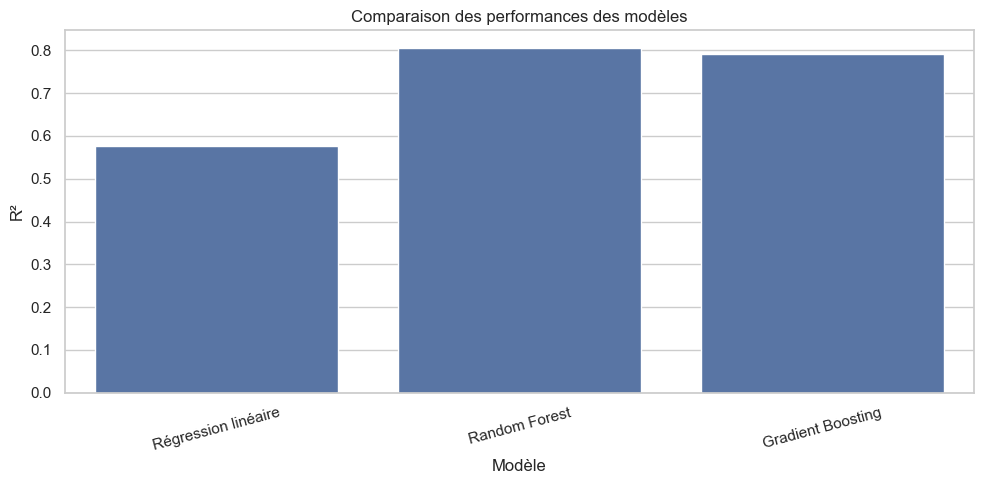

Graphique sauvegardé avec succès.


In [39]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=resultats,
    x="Modèle",
    y="R²"
)

plt.title("Comparaison des performances des modèles")
plt.xlabel("Modèle")
plt.ylabel("R²")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig("../reports/model_comparison_r2.png", dpi=300, bbox_inches="tight")
plt.show()

print("Graphique sauvegardé avec succès.")

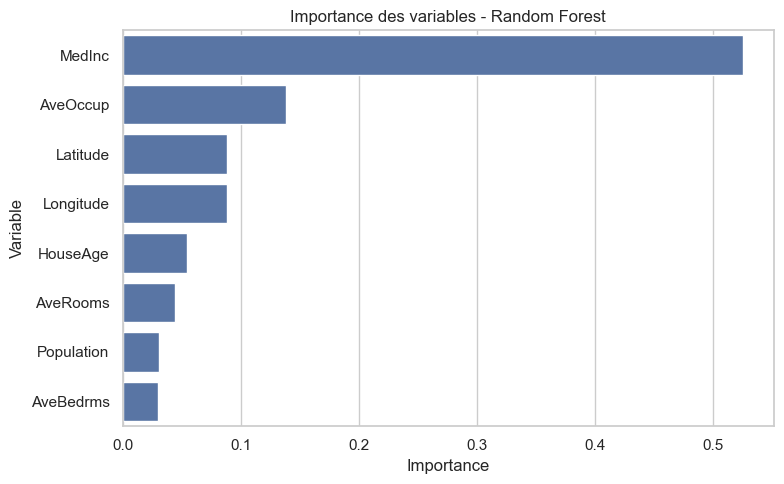

Graphique d'importance sauvegardé avec succès.


In [40]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Variable"
)

plt.title("Importance des variables - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.tight_layout()

plt.savefig(
    "../reports/feature_importance_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Graphique d'importance sauvegardé avec succès.")

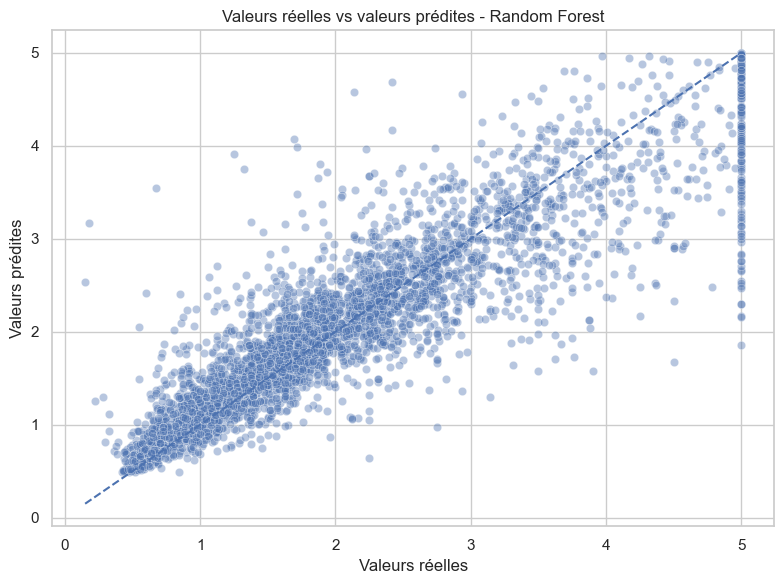

Graphique réel vs prédit sauvegardé avec succès.


In [41]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_forest,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Valeurs réelles vs valeurs prédites - Random Forest")
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.tight_layout()

plt.savefig(
    "../reports/actual_vs_predicted_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Graphique réel vs prédit sauvegardé avec succès.")

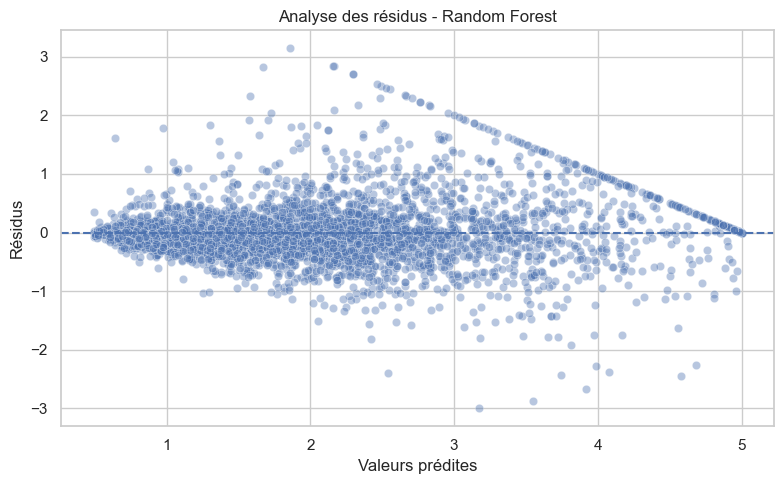

Graphique des résidus sauvegardé avec succès.


In [42]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_pred_forest,
    y=erreurs,
    alpha=0.4
)

plt.axhline(0, linestyle="--")

plt.title("Analyse des résidus - Random Forest")
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.tight_layout()

plt.savefig(
    "../reports/residuals_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Graphique des résidus sauvegardé avec succès.")

In [4]:
import os

print("=== STRUCTURE FINALE DU PROJET ===\n")

for dossier in ["../data", "../models", "../notebooks", "../reports"]:
    print(f"📁 {dossier}")
    for fichier in os.listdir(dossier):
        print("   └──", fichier)
    print()

print("📄 Fichiers principaux :")

for fichier in ["../README.md", "../requirements.txt"]:
    print("   ✅" if os.path.exists(fichier) else "   ❌", fichier)

=== STRUCTURE FINALE DU PROJET ===

📁 ../data

📁 ../models
   └── random_forest_california_housing.joblib

📁 ../notebooks
   └── California_Housing_Price_Prediction.ipynb

📁 ../reports
   └── actual_vs_predicted_random_forest.png
   └── feature_importance_random_forest.png
   └── model_comparison_r2.png
   └── residuals_random_forest.png

📄 Fichiers principaux :
   ✅ ../README.md
   ✅ ../requirements.txt


In [2]:
import os

print("Contenu de reports/figures :")

for fichier in os.listdir("../reports/figures"):
    print("   └──", fichier)

Contenu de reports/figures :


In [3]:
import shutil
import os

# Supprimer reports/figures
if os.path.exists("../reports/figures"):
    shutil.rmtree("../reports/figures")

# Supprimer les checkpoints Jupyter
for dossier in [
    "../reports/.ipynb_checkpoints",
    "../notebooks/.ipynb_checkpoints"
]:
    if os.path.exists(dossier):
        shutil.rmtree(dossier)

print("Nettoyage terminé avec succès.")

Nettoyage terminé avec succès.
